In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 79.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=00dc9dca21118eed30598809c6ee48cb11ac83ce55333f9aabfc4207a282a2de
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


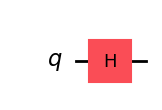

In [2]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [3]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [4]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [5]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [6]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

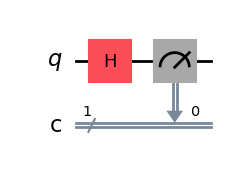

In [7]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [8]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [9]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 502, '0': 522}


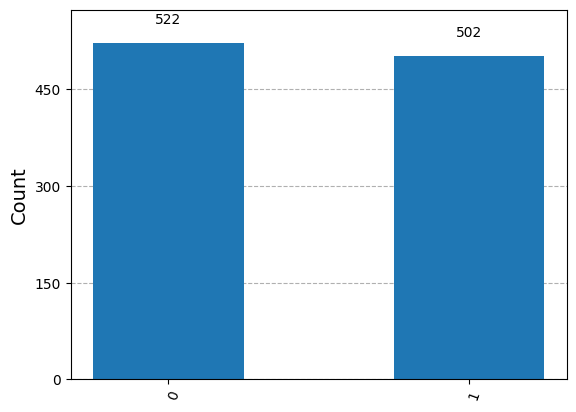

In [10]:
# We can also produce a graph

plot_histogram(counts)

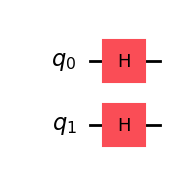

In [11]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [12]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

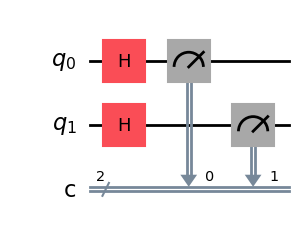

In [13]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

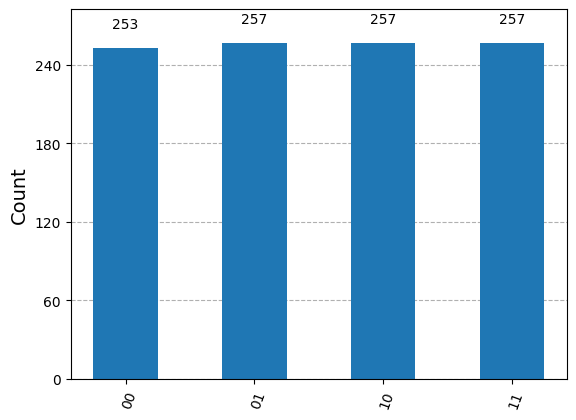

In [14]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

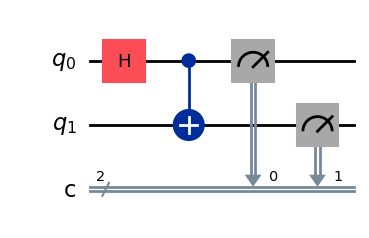

In [15]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

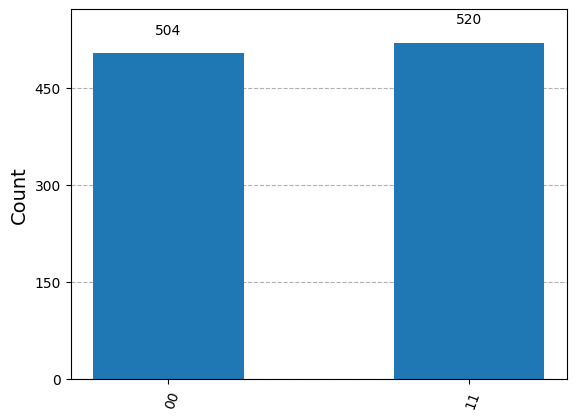

In [16]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [17]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
circuit1 = QuantumCircuit(2, 2)
circuit1.h(0)
circuit1.cx(0, 1)
circuit1.draw("mpl")
# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

In [18]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?